# DAY2 — Batch 2 최종 테스트

CV와 Batch 1 Hold-out 뒤에 고정한 Linear Regression을 Batch 1 유효 36개로 학습하고 Batch 2의 39개를 평가한다. 테스트 점수를 보고 설정을 다시 고르지 않는다.

Feature는 ΔQ 분산의 log10 값 하나, Target은 변환하지 않은 전체 수명이다.

In [1]:
from pathlib import Path
import sys
ROOT=next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/day2_dataset.py').is_file())
sys.path.insert(0,str(ROOT))
import pandas as pd
from IPython.display import display,Image
from src.day2_batch2_evaluation import evaluate_batch2,TRAIN,TEST,save_figures
print('Python:',sys.executable)
train=pd.read_parquet(ROOT/TRAIN);test=pd.read_parquet(ROOT/TEST)
model,predictions,metrics=evaluate_batch2(train,test)
save_figures(predictions)
display(pd.Series(metrics,name='Evaluation'))
display(predictions.sort_values('ape_pct',ascending=False)[['cell_id','actual_life','predicted_life','error_cycles','ape_pct']].head(10).round(2))

Python: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python


model                                        Linear Regression
feature                                       log10_deltaQ_var
target                                untransformed cycle_life
train_batch                                             batch1
train_n                                                     36
test_batch                                              batch2
test_n                                                      39
test_mape_pct                                        25.606115
test_mae_cycles                                     129.234856
test_rmse_cycles                                    153.029437
nonpositive_prediction_n                                     0
target_mape_pct                                            9.1
test_minus_target_mape_pp                            16.506115
holdout_mape_pct                                      9.080207
development_cv_mean_fold_mape_pct                     8.616772
test_minus_holdout_mape_pp                           16

,cell_id,actual_life,predicted_life,error_cycles,ape_pct
18,18,449.0,744.28,295.28,65.76
6,6,393.0,650.71,257.71,65.57
15,15,396.0,643.43,247.43,62.48
2,2,424.0,613.86,189.86,44.78
27,29,452.0,639.20,187.20,41.42
11,11,449.0,627.14,178.14,39.67
22,24,514.0,709.22,195.22,37.98
9,9,791.0,1080.62,289.62,36.61
26,28,437.0,594.42,157.42,36.02
17,17,471.0,635.03,164.03,34.83


## 전체 성능과 셀별 오차

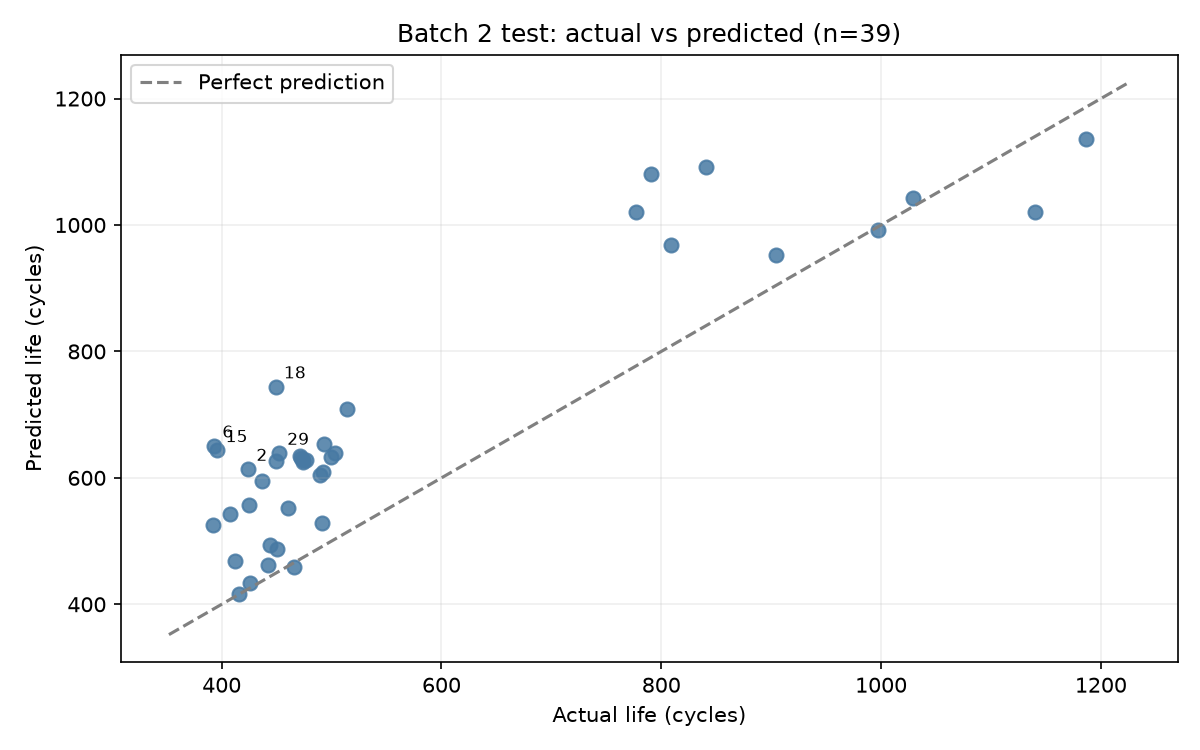

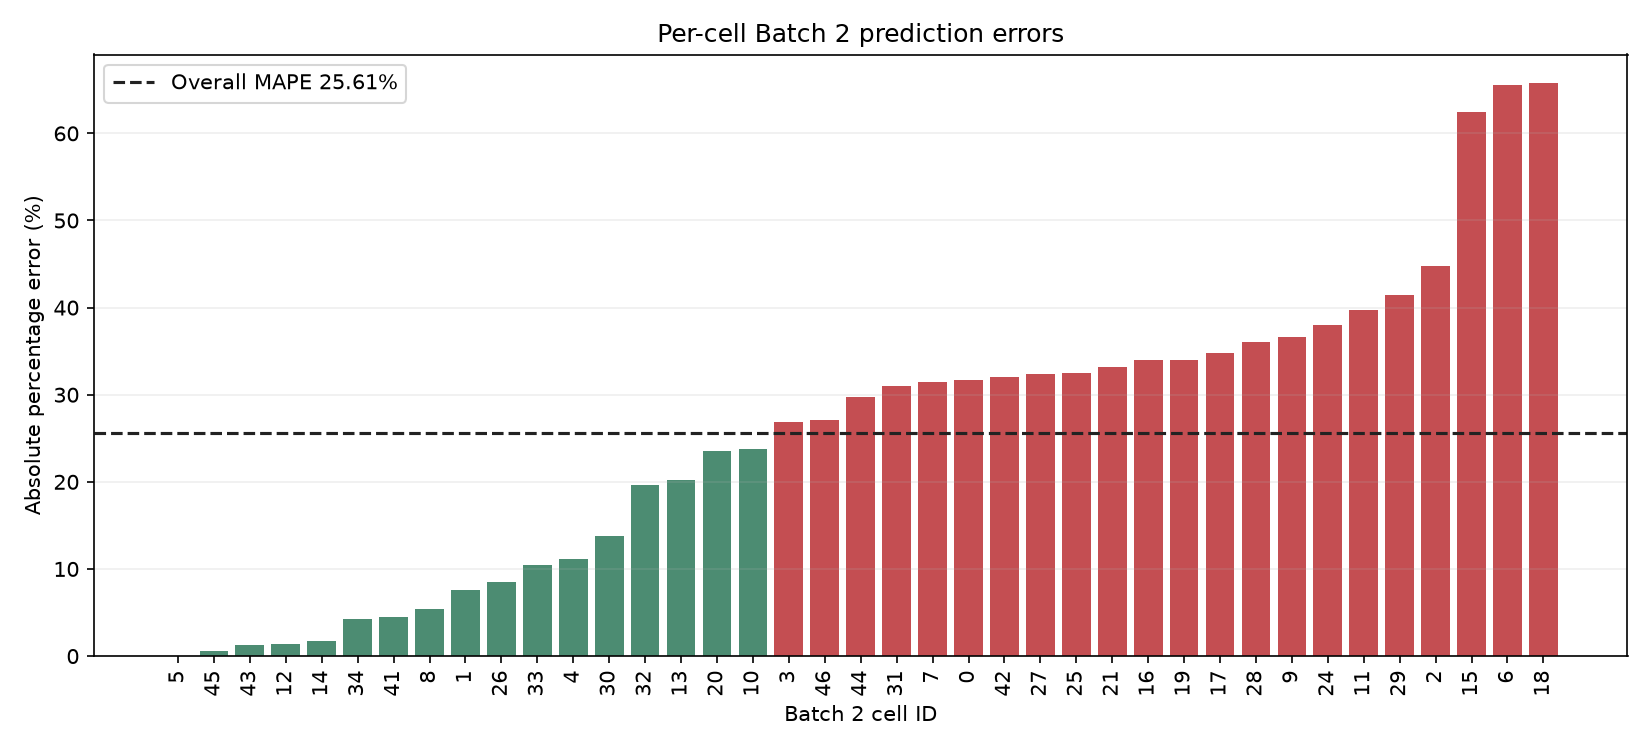

Target gap: +16.51%p


In [2]:
display(Image(filename=str(ROOT/'outputs/figures/day2/batch2_evaluation/01_actual_vs_predicted.png')))
display(Image(filename=str(ROOT/'outputs/figures/day2/batch2_evaluation/02_cell_errors.png')))
assert metrics['test_n']==39 and metrics['train_n']==36
assert not metrics['batch2_used_for_tuning']
print(f"Target gap: {metrics['test_minus_target_mape_pp']:+.2f}%p")

## 다음 분석 아이디어

Batch 2 MAPE가 기준보다 높고 실제 수명을 크게 예측한 셀이 많다. 학습·테스트 수명과 Feature, 프로토콜 구성을 비교해볼 수 있다. 이 점수에 맞춰 모델을 다시 선택하면 Batch 2가 독립 평가 역할을 잃으므로, 후속 모델 실험은 별도 설계가 필요하다.